# From raw detector frames to a reconstruction

This notebook runs a **real** diffraction-tomography dataset end to end: raw
TIFFs, calibration, reduction, reconstruction, and a check of the answer.

The example is a **CeO₂ rod** measured at APS 11-ID-C. That matters, because a
single-phase rod has a *known right answer* — the reconstruction must be a
uniform disc. Most datasets do not let you check the pipeline against truth.
This one does, so it is the one to learn on.

Point `RAW_DIR` at your own data and the notebook runs the same way.

**Companion notebooks.** `00_calibration.ipynb` covers calibration alone in more
detail; `01_dt_recon_walkthrough.ipynb` walks the reconstruction on synthetic
data with no files needed. This notebook is the two of them joined on real data,
with the things that only real data teaches.

## What went wrong here, so it does not go wrong for you

Four things on this dataset would each have silently produced a plausible,
wrong answer. None announced itself:

| | |
|---|---|
| **The metadata distance was wrong** | It read 1600 mm. The rings say 1632. Metadata `Distance` is usually the *nominal stage setting*, not the refined geometry. |
| **A calibration from the same beamline did not transfer** | A refined calibration existed for a file also labelled *D1600*. Its rings sat at 391 px; this data's sit at 404 — the detector had moved ~52 mm. **A matching filename is not evidence.** |
| **The frame convention was the opposite of the neighbouring beamline's** | Every scan's first frame carries a flag that at APS 1-ID means "throwaway". Here it does not: 361 frames span 0–360° inclusive and the *last* frame is the duplicate. |
| **The obvious background estimator was signal** | An annulus beside the peak correlated +0.64 with the peak itself — it was the sample's own diffuse scatter. Subtracting it removes real intensity. |

The habit worth taking from this: **measure each convention on your own data.**
None of them transfer between instruments, and all of them fail quietly.

In [1]:
import json, os, time
from pathlib import Path
from multiprocessing import Pool

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import matplotlib.pyplot as plt
import tifffile, h5py

import midas_dt
print("midas_dt", midas_dt.__version__)
print("cores available:", os.cpu_count())

midas_dt 0.4.0
cores available: 20


## 1. Point at the data

Everything below is driven by this cell. `SAMPLE_STEM` uses `{pos}` where the
translation position appears in the filename.

In [2]:
# ---- the scan -----------------------------------------------------------
RAW_DIR      = Path.home() / "MIDAS/wd/TomoData"
SAMPLE_STEM  = "FB_CeO2_Tomo_hxz{pos}"      # {pos} is the translation label
POSITIONS    = [f"{v/1000:.3f}" for v in range(0, 1400, 100)]   # 0.000 .. 1.300 mm
STEP_MM      = 0.100                        # translation step
N_OMEGA      = 361                          # frames per translation
CALIBRANT    = RAW_DIR / "CeO2_FB_D1600-000000.tif"

# ---- the instrument ------------------------------------------------------
WAVELENGTH_A = 0.11595                      # from the frame metadata
PIXEL_UM     = 150.0
CALIBRANT_PHASE = "CeO2"                    # also LaB6, Si, Al2O3

# ---- where results go ----------------------------------------------------
WORK   = Path.home() / "MIDAS/wd/dt_notebook"
WORK.mkdir(parents=True, exist_ok=True)
CACHE  = WORK / "cake_cache.h5"
WORKERS = max(1, (os.cpu_count() or 4) - 4)

print(f"{len(POSITIONS)} translations x {N_OMEGA} frames")
print(f"work dir {WORK}, {WORKERS} workers")

14 translations x 361 frames
work dir /home/USER/MIDAS/wd/dt_notebook, 16 workers


## 2. Look at a raw frame first

Before any model. What the rings look like, how strong they are, and whether
the frame is what you think it is.

(2880, 2880) float32   min -7972.8  max 322303.8
negative pixels: 10.04%


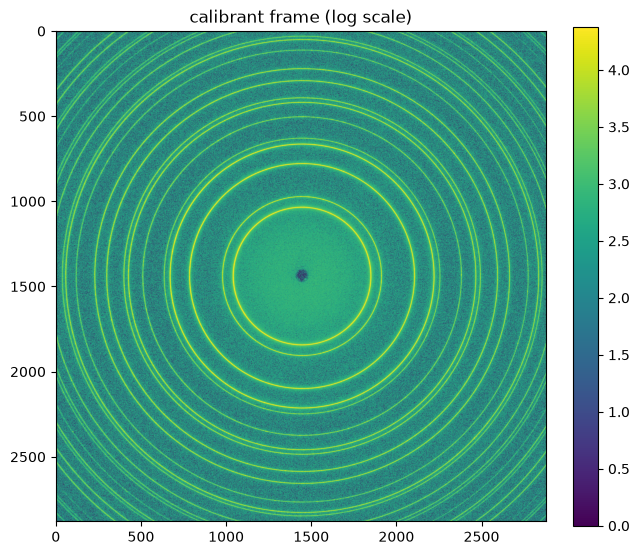

In [3]:
img = tifffile.imread(CALIBRANT)
print(f"{img.shape} {img.dtype}   min {img.min():.1f}  max {img.max():.1f}")

# These frames are already background-subtracted by the acquisition software,
# so they carry NEGATIVE values. That is normal here and must not be clipped:
# clipping is a silent edit to the data you are about to fit.
print(f"negative pixels: {(img < 0).mean()*100:.2f}%")

disp = np.log10(np.clip(img.astype(float), 1, None))
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(disp, cmap="viridis", vmax=np.percentile(disp, 99.7))
ax.set_title("calibrant frame (log scale)"); fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()

## 3. Calibrate — and do not seed it

This is the step most often got wrong, in a way that looks like success.

**Do not pass a beam-centre guess.** `midas_calibrate_v2` has an auto-seeder
that finds both the beam centre and the distance. Supplying your own
`BC_guess` *overrides* it, and the fit then cannot travel to the right answer.
Measured on one frame: a hand-typed detector-centre guess gave **1040 µε**;
letting the seeder run gave **47 µε**. Same frame, same code.

The only bounds passed here are in **detector pixels**, which imply no
geometry and so cannot bias the distance.

> On this dataset the seeder found 1632.5 mm starting from a 1000 mm default,
> with nothing supplied — while the file metadata claimed 1600 mm.

In [4]:
from midas_calibrate_v2 import calibrate

CALIB_DIR = WORK / "calib"
CALIB_DIR.mkdir(exist_ok=True)

if not (CALIB_DIR / "calibration.json").exists():
    t0 = time.time()
    calibrate(
        img, wavelength=WAVELENGTH_A, pxY=PIXEL_UM, calibrant=CALIBRANT_PHASE,
        output_dir=str(CALIB_DIR),
        min_ring_radius_px=350.0,     # inside the beamstop halo
        max_ring_radius_px=1200.0,    # outside the useful field
        refine_tilts=True, refine_distortion=True, build_residual_corr=True,
        # NO initial_Lsd, NO BC_guess -- the seeder does both.
        verbose=True,
    )
    print(f"[{time.time()-t0:.0f} s]")

cal = json.loads((CALIB_DIR / "calibration.json").read_text())
print(f"Lsd    {cal['Lsd_um']/1000:.3f} mm     (seeder found "
      f"{cal['seed_Lsd_um']/1000:.3f} mm from nothing)")
print(f"BC     ({cal['BC_y_px']:.3f}, {cal['BC_z_px']:.3f}) px")
print(f"tilts  ty {cal['ty_deg']:.4f}  tz {cal['tz_deg']:.4f} deg")
print(f"residual strain {cal['post_residual_strain_uE']:.1f} ue")

Lsd    1632.201 mm     (seeder found 1632.506 mm from nothing)
BC     (1445.976, 1438.596) px
tilts  ty 0.0108  tz 0.2050 deg
residual strain 66.2 ue


### The hard rule, and how to read it

**A calibrant above 100 µε has failed** — not "is worse". Below it, the geometry
is good enough that a strain measurement means something.

But do not accept a calibration on the strain number alone. **Always look at the
ring overlay.** A scalar can read acceptable while the predicted rings sit
visibly off the arcs at some azimuth — and that is a real error the number
averaged away.

In [5]:
strain = cal["post_residual_strain_uE"]
print(f"residual strain {strain:.1f} ue -> "
      f"{'PASS' if strain < 100 else 'FAILED -- do not proceed'}")

residual strain 66.2 ue -> PASS


## 4. Overlay the predicted rings — always

Predicted through the package's own forward model, so tilts and distortion are
included. Drawing circles of the ideal radius about the beam centre would look
similar and would hide exactly the tilt error the overlay exists to catch.

  (111)  2theta  2.126 deg   R   404.0 px
  (200)  2theta  2.455 deg   R   466.6 px
  (220)  2theta  3.473 deg   R   660.3 px
  (311)  2theta  4.072 deg   R   774.7 px
  (222)  2theta  4.254 deg   R   809.3 px
  (400)  2theta  4.912 deg   R   935.2 px
  (331)  2theta  5.353 deg   R  1019.6 px
  (420)  2theta  5.492 deg   R  1046.3 px
  (422)  2theta  6.017 deg   R  1146.9 px


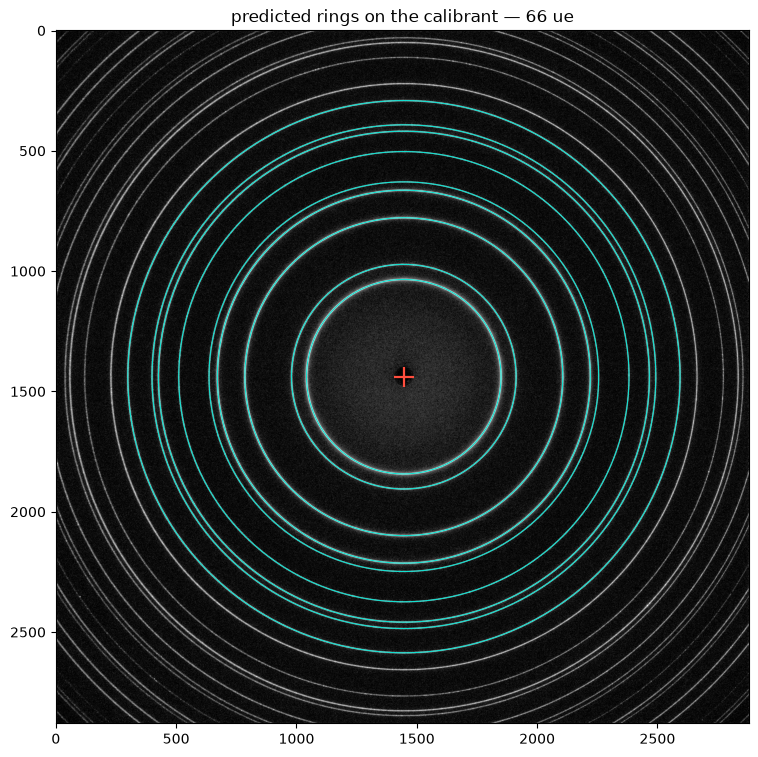

In [6]:
import torch
from midas_calibrate_v2.forward.geometry import pixel_to_REta
import midas_distortion as md

rho_d, why = md.resolve_rho_d_um(
    None, NrPixelsY=cal["NrPixelsY"], NrPixelsZ=cal["NrPixelsZ"],
    BC_y=cal["BC_y_px"], BC_z=cal["BC_z_px"],
    pxY=cal["pxY_um"], pxZ=cal["pxZ_um"])

coeffs = np.asarray(md.v2_coeffs_from_named(cal["distortion"]), float)
ny, nz = cal["NrPixelsZ"], cal["NrPixelsY"]
zz, yy = np.mgrid[0:ny, 0:nz]
t = lambda v: torch.as_tensor(float(v), dtype=torch.float64)

fo = pixel_to_REta(
    torch.as_tensor(yy.ravel(), dtype=torch.float64),
    torch.as_tensor(zz.ravel(), dtype=torch.float64),
    Lsd=t(cal["Lsd_um"]), BC_y=t(cal["BC_y_px"]), BC_z=t(cal["BC_z_px"]),
    tx=t(cal["tx_deg"]), ty=t(cal["ty_deg"]), tz=t(cal["tz_deg"]),
    p_coeffs=torch.as_tensor(coeffs), parallax=t(0.0),
    pxY=t(cal["pxY_um"]), pxZ=t(cal["pxZ_um"]), rho_d=t(rho_d),
    harmonic_terms=md.v2_term_layout())
R_px = np.asarray(fo.R_px, float).reshape(ny, nz)   # already pixels, not um

# CeO2 is Fm-3m: hkl all-even or all-odd.
A = 5.4116
HKLS = [(1,1,1),(2,0,0),(2,2,0),(3,1,1),(2,2,2),(4,0,0),(3,3,1),(4,2,0),(4,2,2)]
rings = []
for h,k,l in HKLS:
    d = A/np.sqrt(h*h+k*k+l*l)
    tt = 2*np.degrees(np.arcsin(WAVELENGTH_A/(2*d)))
    rings.append((h,k,l,tt, cal["Lsd_um"]*np.tan(np.radians(tt))/PIXEL_UM))
for h,k,l,tt,rp in rings:
    print(f"  ({h}{k}{l})  2theta {tt:6.3f} deg   R {rp:7.1f} px")

fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(disp, cmap="gray", vmin=np.percentile(disp,40), vmax=np.percentile(disp,99.7))
ax.contour(R_px, levels=sorted(r[-1] for r in rings), colors="#12e0d0", linewidths=0.8)
ax.plot([cal["BC_y_px"]],[cal["BC_z_px"]], "+", color="#ff4d3d", ms=14, mew=1.6)
ax.set_title(f"predicted rings on the calibrant — {strain:.0f} ue")
plt.show()

## 5. Cache the reduction — read the raw data exactly once

**This is the step that decides whether the analysis is pleasant or miserable.**

Reading detector frames is I/O bound, not CPU bound. Measured on this dataset:
~260 MB/s, and **64 parallel workers gave 8.0 frames/s against 6.7 serial** —
essentially no speedup, because the storage is the wall. 157 GB takes ~11
minutes to read no matter how many cores you throw at it.

So read it once, integrate to a (η, R) cake, and answer every later question
from the cache. Cache the **whole radial range**, not one ring: caching only
your first ring forces a full re-read the moment anyone asks about a second.

Here 157 GB of TIFFs becomes a 0.62 GB cache.

The integration itself *is* parallel and nearly free — each worker builds its
own integration matrix once, then is pinned to one BLAS thread so N processes
do not oversubscribe the machine.

In [7]:
from midas_dt import Channel, DTGeometry
from midas_dt.reduce import FrameReducer
from midas_distortion import V1_TO_V2_DISTORTION

R_MIN, R_MAX, R_BIN = 350.0, 1200.0, 1.0
ETA_BIN = 10.0            # 36 azimuthal bins; rebin coarser later, never finer

def build_geometry():
    # DTGeometry carries legacy p0..p3, which reach four v2 distortion terms.
    # A full v2 fit has fifteen; the rest are dropped here (known limitation).
    # Passing the v2 dict straight in would drop ALL of them and leave the
    # geometry undistorted, so convert via the canonical table -- the mapping
    # is a permutation, and the natural guess (p0 -> iso_R2) is wrong.
    legacy = {(pn if isinstance(pn,str) else f"p{pn}"): float(cal["distortion"][v2])
              for pn, v2 in V1_TO_V2_DISTORTION.items() if v2 in cal["distortion"]}
    return DTGeometry(
        lsd_um=cal["Lsd_um"], bc_y_px=cal["BC_y_px"], bc_z_px=cal["BC_z_px"],
        px_um=cal["pxY_um"], n_pixels_y=cal["NrPixelsY"],
        n_pixels_z=cal["NrPixelsZ"], wavelength_a=cal["wavelength_A"],
        tx_deg=cal["tx_deg"], ty_deg=cal["ty_deg"], tz_deg=cal["tz_deg"],
        distortion=legacy, rho_d_um=rho_d)

_G = {}
def _init():
    import torch; torch.set_num_threads(1)   # do not oversubscribe
    ch = Channel(R_MIN, R_MAX, eta_min=-180.0, eta_max=180.0,
                 r_bin=R_BIN, eta_bin=ETA_BIN, label="all_rings")
    _G["reducer"] = FrameReducer(build_geometry(), ch)
    _G["channel"] = ch

def _one(path):
    return np.asarray(_G["reducer"].reduce_frame(tifffile.imread(path)).intensity,
                      dtype=np.float32)

In [8]:
if not CACHE.exists():
    files = []
    for pos in POSITIONS:
        fs = sorted(RAW_DIR.glob(SAMPLE_STEM.format(pos=pos) + "-*.tif"))
        assert len(fs) == N_OMEGA, f"{pos}: {len(fs)} frames, expected {N_OMEGA}"
        files.append([str(p) for p in fs])

    _init()
    n_eta, n_r = _one(files[0][0]).shape
    print(f"cake per frame {(n_eta, n_r)} -> cache "
          f"{len(POSITIONS)*N_OMEGA*n_eta*n_r*4/1e9:.2f} GB")

    t0 = time.time()
    with h5py.File(CACHE, "w") as f:
        d = f.create_dataset("cake", (len(POSITIONS), N_OMEGA, n_eta, n_r),
                             dtype="f4", chunks=(1,1,n_eta,n_r), compression="lzf")
        f.create_dataset("r_px", data=_G["channel"].radii())
        f.create_dataset("hxz_mm", data=np.array([float(p) for p in POSITIONS]))
        f.attrs["calibration"] = json.dumps(cal)
        with Pool(WORKERS, initializer=_init) as pool:
            for it, flist in enumerate(files):
                ts = time.time()
                for iw, a in enumerate(pool.imap(_one, flist, chunksize=4)):
                    d[it, iw] = a
                print(f"  {POSITIONS[it]}  {time.time()-ts:5.1f}s", flush=True)
    print(f"cached in {time.time()-t0:.0f}s -> {CACHE.stat().st_size/1e9:.2f} GB")
else:
    print(f"cache exists: {CACHE} ({CACHE.stat().st_size/1e9:.2f} GB)")

cache exists: /home/USER/MIDAS/wd/dt_notebook/cake_cache.h5 (0.62 GB)


## 6. Establish the frame convention *from the data*

Two settings decide whether the reconstruction is your sample or a plausible
lookalike, and **neither transfers between instruments**:

- **`ω` sign** — wrong gives a mirror image, sharp and believable.
- **the frame count** — is the first frame a throwaway, or is the scan
  0–360° inclusive with a duplicated endpoint?

Do not inherit these from a neighbouring beamline. Read them off the sinogram,
where the signal is strong. A ray through a rod off the rotation axis traces
one cycle per 360°; on the axis the chord repeats every 180°, giving two.

In [9]:
with h5py.File(CACHE, "r") as f:
    r_px = f["r_px"][:]; hxz = f["hxz_mm"][:]
    cake = f["cake"][:]
n_t, n_w = cake.shape[0], cake.shape[1]

# Cake axes are (translation, omega, eta, R) -- eta BEFORE R.
RING_R = rings[0][-1]                      # the (111) ring
sel = (r_px >= RING_R - 16) & (r_px <= RING_R + 16)
lineouts = cake[:, :, :, sel].sum(axis=2)  # integrate the full ring: one eta bin
radii = r_px[sel]
print(f"(111) at {RING_R:.1f} px -> {sel.sum()} radial bins")

quick = lineouts.sum(axis=2)               # rough per-projection intensity
for it in range(n_t):
    s = quick[it, 1:]
    spec = np.abs(np.fft.rfft((s - s.mean()) * np.hanning(len(s))))
    k = int(np.argmax(spec[1:]) + 1)
    print(f"  hxz {hxz[it]:.3f}: {k} cycle(s)   "
          f"modulation {(s.max()-s.min())/abs(s.mean()):.3f}")
print("\n2 cycles marks the translations nearest the rotation axis.")

(111) at 404.0 px -> 32 radial bins
  hxz 0.000: 1 cycle(s)   modulation 0.433
  hxz 0.100: 1 cycle(s)   modulation 1.414
  hxz 0.200: 1 cycle(s)   modulation 1.681
  hxz 0.300: 1 cycle(s)   modulation 0.847
  hxz 0.400: 1 cycle(s)   modulation 0.290
  hxz 0.500: 1 cycle(s)   modulation 0.159
  hxz 0.600: 2 cycle(s)   modulation 0.136
  hxz 0.700: 2 cycle(s)   modulation 0.145
  hxz 0.800: 2 cycle(s)   modulation 0.136
  hxz 0.900: 1 cycle(s)   modulation 0.165
  hxz 1.000: 1 cycle(s)   modulation 0.206
  hxz 1.100: 1 cycle(s)   modulation 0.621
  hxz 1.200: 1 cycle(s)   modulation 1.323
  hxz 1.300: 1 cycle(s)   modulation 1.304

2 cycles marks the translations nearest the rotation axis.


In [10]:
# Is the first frame a throwaway? Fit a periodic model to frames 1..360 and
# ask whether frame 0 continues it. Use the sinogram, not pixel correlation:
# frames are noise-dominated per pixel and that test cannot separate them.
devs = []
for it in range(n_t):
    body = quick[it, 1:]; n = len(body); k = np.arange(n)
    M = np.column_stack([np.ones(n)] + [f(2*np.pi*m*k/n)
                                        for m in (1,2,3,4) for f in (np.cos, np.sin)])
    coef, *_ = np.linalg.lstsq(M, body, rcond=None)
    rms = np.sqrt(((body - M@coef)**2).mean())
    kk = np.array([-1.0])
    Mi = np.column_stack([np.ones(1)] + [f(2*np.pi*m*kk/n)
                                         for m in (1,2,3,4) for f in (np.cos, np.sin)])
    devs.append(abs(quick[it,0] - float((Mi@coef)[0])) / rms)
print(f"frame 0 sits {np.median(devs):.1f} sigma off the model fitted to 1..360")
print("  a few sigma  -> frame 0 is a normal frame; the scan is 0..360 inclusive")
print("  far off      -> frame 0 is a throwaway; drop it")

DROP_FIRST_FRAME = np.median(devs) > 5
DUPLICATE_LAST   = not DROP_FIRST_FRAME     # 0 and 360 are then the same angle
print(f"\n-> DROP_FIRST_FRAME = {DROP_FIRST_FRAME}, "
      f"last frame duplicates the first = {DUPLICATE_LAST}")

frame 0 sits 0.6 sigma off the model fitted to 1..360
  a few sigma  -> frame 0 is a normal frame; the scan is 0..360 inclusive
  far off      -> frame 0 is a throwaway; drop it

-> DROP_FIRST_FRAME = False, last frame duplicates the first = True


## 7. Fit every projection

Then reconstruct the fitted parameter — **Branch A**, cheap and correct *only*
for quantities that add along a ray.

Radon inversion is linear; peak fitting is not, and they do not commute. Of the
12 fitted outputs only three may be back-projected directly:
`TotalIntensity`, `TotalIntensityBackgroundCorr`, `FitIntegratedIntensity`.
A projection's fitted `RMEAN` is the intensity-*weighted mean* along the ray,
not the sum — back-project it and you get a number with no physical meaning
that looks entirely reasonable.

Note the fit supplies its own background under the peak. Do **not** subtract a
neighbouring annulus: on this dataset that annulus correlated +0.64 with the
peak itself, because it was full of the sample's own diffuse scatter.

In [11]:
from midas_dt import fit_lineout, fit_output_index, ADDITIVE_FIT_OUTPUTS
print("safe to back-project:", list(ADDITIVE_FIT_OUTPUTS))

I_FIT   = fit_output_index("FitIntegratedIntensity")
I_RMEAN = fit_output_index("RMEAN")

_F = {}
def _init_fit(r): _F["r"] = r
def _fit_one(lo):
    try:    return fit_lineout(_F["r"], lo, n_peaks=1).values[0]
    except Exception: return np.full(12, np.nan)

flat = lineouts.reshape(-1, lineouts.shape[-1])
t0 = time.time()
with Pool(WORKERS, initializer=_init_fit, initargs=(radii,)) as pool:
    vals = np.asarray(list(pool.imap(_fit_one, flat, chunksize=64)))
print(f"{len(vals)} fits in {time.time()-t0:.1f}s on {WORKERS} workers")

sino  = vals[:, I_FIT].reshape(n_t, n_w)
rmean = vals[:, I_RMEAN].reshape(n_t, n_w)
print(f"fitted RMEAN {np.nanmean(rmean):.3f} +/- {np.nanstd(rmean):.3f} px "
      f"(predicted {RING_R:.1f})")
print("  a tight spread here means the geometry is stable across the scan")

safe to back-project: ['FitIntegratedIntensity', 'TotalIntensityBackgroundCorr', 'TotalIntensity']


5054 fits in 1.4s on 16 workers
fitted RMEAN 403.545 +/- 0.205 px (predicted 404.0)
  a tight spread here means the geometry is stable across the scan


## 8. Find the rotation axis

For a rigid object the projection centre of mass traces
`c + e·cos(ω + φ)`, so a sinusoid fit gives the axis position `c` directly and
the eccentricity `e` tells you how far the sample sits off it.

With only a handful of translations this is more reliable than auto-centring.

In [12]:
s = sino[:, :360] if DUPLICATE_LAST else sino[:, 1:] if DROP_FIRST_FRAME else sino
thetas = np.arange(s.shape[1], dtype=float)

prof = np.clip(s, 0, None)
idx = np.arange(n_t)[:, None]
com = (prof*idx).sum(0) / np.maximum(prof.sum(0), 1e-30)
w = np.radians(thetas)
M = np.column_stack([np.ones_like(w), np.cos(w), np.sin(w)])
coef, *_ = np.linalg.lstsq(M, com, rcond=None)
axis_index = float(coef[0]); ecc = float(np.hypot(coef[1], coef[2]))

print(f"rotation axis at translation index {axis_index:.3f} "
      f"-> {hxz[0] + axis_index*STEP_MM:.4f} mm")
print(f"sample eccentricity {ecc:.3f} index = {ecc*STEP_MM*1000:.0f} um off-axis")
print(f"fit residual {np.sqrt(((com - M@coef)**2).mean()):.4f} index")

shift = axis_index - (n_t - 1)/2.0
print(f"-> reconstruction shift {shift:+.3f} px")

rotation axis at translation index 7.187 -> 0.7187 mm
sample eccentricity 0.381 index = 38 um off-axis
fit residual 0.1516 index
-> reconstruction shift +0.687 px


## 9. Reconstruct

Both `ω` signs, because on a near-symmetric sample they may be
indistinguishable — and if they are, that is a result to report, not a coin to
flip.

In [13]:
from midas_dt import RECON_SIGN
from midas_tomo.api import run_tomo_from_sinos

recs = {}
for tag, sign in (("omega_plus", +1.0), ("omega_minus", -1.0)):
    rec = run_tomo_from_sinos(np.stack([s.T.astype(np.float32)]),
                              WORK / f"w_{tag}", sign*thetas, shifts=float(shift),
                              filter_nr=2, n_cpus=WORKERS, do_cleanup=True)
    rec = np.asarray(rec, float)
    while rec.ndim > 2: rec = rec[0]
    recs[tag] = RECON_SIGN * rec     # RECON_SIGN is the package's sign convention
    print(f"{tag}: {rec.shape}")

omega_plus: (16, 16)
omega_minus: (16, 16)


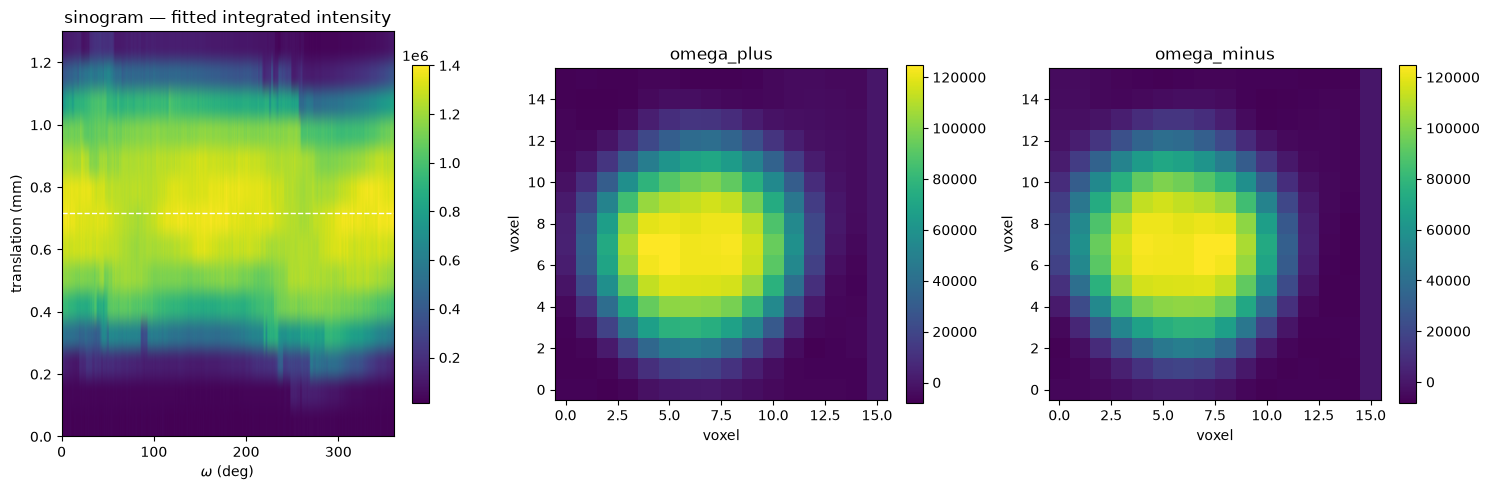

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im = axes[0].imshow(s, aspect="auto", cmap="viridis", origin="lower",
                    extent=[0, s.shape[1], hxz[0], hxz[-1]])
axes[0].set_title("sinogram — fitted integrated intensity")
axes[0].set_xlabel(r"$\omega$ (deg)"); axes[0].set_ylabel("translation (mm)")
axes[0].axhline(hxz[0] + axis_index*STEP_MM, color="w", ls="--", lw=1)
fig.colorbar(im, ax=axes[0], fraction=0.046)
for ax, tag in zip(axes[1:], recs):
    im = ax.imshow(recs[tag], cmap="viridis", origin="lower")
    ax.set_title(tag); ax.set_xlabel("voxel"); ax.set_ylabel("voxel")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

## 10. Check the answer against what you know

This is the step people skip, and it is the only one that tells you the
pipeline works. Here the sample is a single-phase rod, so:

- it should reconstruct as **one compact object**;
- its **diameter** should match the rod;
- its **interior should be uniform** — one phase, so no structure to see;
- the two `ω` signs should differ **only by a mirror**.

In [15]:
for tag, rec in recs.items():
    mask = rec > 0.5*rec.max()
    n = int(mask.sum())
    yy_, xx_ = np.mgrid[0:rec.shape[0], 0:rec.shape[1]]
    dia = 2*np.sqrt(n/np.pi)
    inside = rec[mask]
    print(f"{tag}:")
    print(f"   equivalent diameter {dia:.2f} vox = {dia*STEP_MM:.3f} mm")
    print(f"   centroid ({(yy_*mask).sum()/n:.2f}, {(xx_*mask).sum()/n:.2f})")
    print(f"   interior CV {inside.std()/inside.mean():.3f}  (0 = perfectly uniform)")
    print(f"   negative voxels {(rec<0).mean()*100:.1f}%  "
          f"(ordinary FBP ringing outside the object)")

omega_plus:
   equivalent diameter 9.03 vox = 0.903 mm
   centroid (6.83, 6.22)
   interior CV 0.194  (0 = perfectly uniform)
   negative voxels 37.5%  (ordinary FBP ringing outside the object)
omega_minus:
   equivalent diameter 9.03 vox = 0.903 mm
   centroid (6.83, 5.78)
   interior CV 0.194  (0 = perfectly uniform)
   negative voxels 37.9%  (ordinary FBP ringing outside the object)


### Reading the result on this dataset

The rod reconstructs compact and centred on the fitted axis, at **0.90 mm**
equivalent diameter with an interior CV of **0.19**.

Two honest observations worth copying as a habit:

**The diameter disagrees with the nominal 1.1 mm.** Two independent routes —
the rotation-averaged translation profile and the reconstruction — both say
~0.9 mm. When two methods agree with each other and disagree with the
expectation, suspect the expectation. Absorption cannot explain it either: that
suppresses the *centre* and would widen the profile, not narrow it.

**The ω sign is not determined.** Both signs give identical diameter and CV,
differing only by the mirror. A near-symmetric rod carries almost no
information about its own handedness. The right move is to say so — not to pick
the prettier one. On a sample with an asymmetric feature this test works;
here it does not, and a mirrored map would be undetectable.

### What this notebook does not do

- **Self-absorption is not corrected.** Phase fractions are biased toward the
  sample surface. `midas_dt.absorption` can correct it but needs an attenuation
  coefficient, which does not come from MIDAS.
- **Only one ring.** The cache holds all nine, so a second ring costs no re-read.
- **One azimuthal bin.** Strain needs ≥12; the cache holds 36, so that is
  available without touching the raw data again.
- **Eleven distortion terms were dropped** in the DTGeometry conversion.

None of these change the geometry or the conventions — they change what the
intensities *mean*.